In [54]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

In [ ]:
#
data = yf.Ticker("AAPL") #creates ticker object for apple stocks everything will be referencing this object
data.info # returns a large dict of general comp info: market cap, sector, P/E ratio, 52-week high/low
data.calendar #returns upcoming events like earnings dates and expected EPS ranges
data.analyst_price_targets #retunrs analyst consensus price targets(low, mean, high, current)
data.quarterly_income_stmt #returns the last few quarters of income statement data: rev, gross profit, net income
data.history(period='1mo') # returns a df of daily OHLCV price data for the past 1 month
data.option_chain(data.options[0]).calls # gets the nearest exp dat from the list of options  and fetches 
# the options chain for the date and reutnrs just the call contracts 


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,AAPL260513C00205000,2026-05-11 16:19:59+00:00,205.0,86.95,85.80,89.45,-0.950005,-1.080779,2,NaN,3.238283,True,REGULAR,USD
1,AAPL260513C00230000,2026-05-11 19:18:25+00:00,230.0,61.48,60.60,64.10,7.360001,13.599410,2,0.0,2.248540,True,REGULAR,USD
2,AAPL260513C00245000,2026-05-11 17:15:20+00:00,245.0,46.51,46.55,48.60,-1.840000,-3.805585,130,0.0,1.597658,True,REGULAR,USD
3,AAPL260513C00250000,2026-05-11 15:28:33+00:00,250.0,43.38,40.60,44.45,0.030003,0.069210,1,1.0,1.716310,True,REGULAR,USD
4,AAPL260513C00255000,2026-05-11 19:12:24+00:00,255.0,36.66,35.80,39.20,-1.689999,-4.406776,2,1.0,1.488772,True,REGULAR,USD
5,AAPL260513C00257500,2026-05-08 19:40:59+00:00,257.5,35.40,33.30,36.45,0.000000,0.000000,10,0.0,1.342288,True,REGULAR,USD
6,AAPL260513C00260000,2026-05-11 19:18:25+00:00,260.0,31.59,30.80,34.20,-1.509998,-4.561929,1,6.0,1.331546,True,REGULAR,USD
7,AAPL260513C00265000,2026-05-08 13:43:18+00:00,265.0,28.00,25.85,29.10,0.000000,0.000000,1,0.0,1.149418,True,REGULAR,USD
8,AAPL260513C00267500,2026-05-07 14:19:36+00:00,267.5,22.99,23.35,26.90,0.000000,0.000000,1,0.0,1.137700,True,REGULAR,USD
9,AAPL260513C00270000,2026-05-11 17:27:59+00:00,270.0,21.89,21.85,23.50,-1.680000,-7.127706,219,10.0,0.845705,True,REGULAR,USD


## Simple Moving Average (SMA)

The SMA averages the closing price over the past $n$ days with equal weight:

$$\text{SMA}_t = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}$$

where $P_t$ is the closing price at time $t$ and $n$ is the window size. The first $n-1$ values are undefined ($\text{NaN}$) since there are not enough prior observations to fill the window.

---

## Exponential Moving Average (EMA)

The EMA applies exponentially decaying weights so that recent prices matter more:

$$\text{EMA}_t = \alpha \cdot P_t + (1 - \alpha) \cdot \text{EMA}_{t-1}$$

where the smoothing factor $\alpha$ is:

$$\alpha = \frac{2}{n + 1}$$

As prices get older, the weight $(1-\alpha)^i$ shrinks toward zero — recent prices dominate. Unlike SMA, EMA produces no $\text{NaN}$ gap at the start since it is computed recursively from the first observation.

---

## Why Calculate SMA and EMA?

**Trend Identification**
- Price above SMA/EMA → uptrend; price below → downtrend
- Smooths out day-to-day noise so the broader direction is clearer

**Signal Generation (Crossovers)**
- When a short-term MA crosses above a long-term MA → *golden cross* (bullish signal)
- When it crosses below → *death cross* (bearish signal)

**ML Feature Engineering**
- Raw price is non-stationary (trends upward over time), which hurts model performance
- SMA and EMA give the model a sense of where price has been trending, capturing momentum without overfitting to raw price levels

**EMA vs SMA**
- EMA reacts faster to recent price changes, making it more useful for short-term prediction
- SMA is smoother and better for identifying long-term trends

In [18]:
#simple moving average (30-days)
history = data.history(period='1y')
history['SMA30'] = history['Close'].rolling(window=30).mean() 

#exponential moving average (50 days)
history['EMA50'] = history['Close'].ewm(span=50, adjust=False).mean()

print(history[['Close','SMA30','EMA50']])

                                Close       SMA30       EMA50
Date                                                         
2025-05-12 00:00:00-04:00  210.150482         NaN  210.150482
2025-05-13 00:00:00-04:00  212.283997         NaN  210.234149
2025-05-14 00:00:00-04:00  211.685822         NaN  210.291078
2025-05-15 00:00:00-04:00  210.808487         NaN  210.311368
2025-05-16 00:00:00-04:00  210.619064         NaN  210.323435
...                               ...         ...         ...
2026-05-05 00:00:00-04:00  284.179993  263.536999  264.873603
2026-05-06 00:00:00-04:00  287.510010  264.732666  265.761305
2026-05-07 00:00:00-04:00  287.440002  265.893333  266.611450
2026-05-08 00:00:00-04:00  293.320007  267.241000  267.658844
2026-05-11 00:00:00-04:00  292.679993  268.703666  268.640066

[251 rows x 3 columns]


## Lagged Returns 

---

The three methods of Lagged Retunrs that I will be implmenting include:
- Linear Regression
- Garch-in-mean Models
- Rolling returns


**Linear Regression**
It is often used to test the relationship between one stock's lagged returns and another's future returns 


**Garch-in-mean Models**
Used to incorproate lagged returns into conditional variance calculations for better forecasting 

**Rolling returns**
Calculating performance over specific past periods, such as the past 12 months excluding the most recent one




We are using the normal equation for this Linear Regression implementation, we only have a small to medium sized data set, so no Gradient Descent is needed 

Normal Equation:

$${\theta} = (X^T X)^{-1} X^T y$$



Step 1: $X^T X$

$X$ is an $n \times p$ matrix (rows = observations, cols = features). You can't invert a non-square matrix, so you multiply by its transpose first to get a square $p \times p$ matrix that you can invert.

But it's not just a math trick — $X^T X$ actually captures how much variance and covariance exists across your features.

Step 2: $(X^T X)^{-1}$

Inverting it "undoes" the feature relationships — similar to how dividing by a number undoes multiplication. This is what allows you to isolate $\theta$.

Think of the scalar version: if $y = ax$, then $x = a^{-1}y$. The matrix version is the same idea but for systems of equations.

Step 3: $X^T y$

$X^T y$ projects your target $y$ onto the feature space — it captures how much each feature correlates with the output.

Putting it together

Starting from $y = X\theta$, you can't just divide both sides by $X$ since matrix division doesn't exist. So instead:

$$X^T y = X^T X \theta$$
$$(X^T X)^{-1} X^T y = \theta$$

You multiply both sides by $(X^T X)^{-1}$ to isolate $\theta$ — same as dividing both sides by a number in algebra, just in matrix form.

In [43]:
#Linear Regression 
def linear_regression(X,y):
    x_b = np.c_[np.ones((len(X),1)),X]

    theta = np.linalg.inv(x_b.T @ x_b) @ x_b.T @y

    return theta 

In [44]:
history['Return'] = history['Close'].pct_change()

#each lag shifts the return column down by n days
history['Lag1'] = history['Return'].shift(1) #returns on day t-1
history['Lag2'] = history['Return'].shift(2) #returns on day t-2
history['Lag3'] = history['Return'].shift(3) #returns on day t-3

history[['Close', 'Return', 'Lag1', 'Lag2', 'Lag3']]


,Close,Return,Lag1,Lag2,Lag3
Date,,,,,
2025-05-12 00:00:00-04:00,210.150482,NaN,NaN,NaN,NaN
2025-05-13 00:00:00-04:00,212.283997,0.010152,NaN,NaN,NaN
2025-05-14 00:00:00-04:00,211.685822,-0.002818,0.010152,NaN,NaN
2025-05-15 00:00:00-04:00,210.808487,-0.004145,-0.002818,0.010152,NaN
2025-05-16 00:00:00-04:00,210.619064,-0.000899,-0.004145,-0.002818,0.010152
...,...,...,...,...,...
2026-05-05 00:00:00-04:00,284.179993,0.026551,-0.011816,0.032394,0.004368
2026-05-06 00:00:00-04:00,287.510010,0.011718,0.026551,-0.011816,0.032394
2026-05-07 00:00:00-04:00,287.440002,-0.000243,0.011718,0.026551,-0.011816


In [45]:
#dropped all rows with NaN
history[['Close', 'Return', 'Lag1', 'Lag2', 'Lag3']].dropna()

,Close,Return,Lag1,Lag2,Lag3
Date,,,,,
2025-05-16 00:00:00-04:00,210.619064,-0.000899,-0.004145,-0.002818,0.010152
2025-05-19 00:00:00-04:00,208.146576,-0.011739,-0.000899,-0.004145,-0.002818
2025-05-20 00:00:00-04:00,206.232422,-0.009196,-0.011739,-0.000899,-0.004145
2025-05-21 00:00:00-04:00,201.476883,-0.023059,-0.009196,-0.011739,-0.000899
2025-05-22 00:00:00-04:00,200.749100,-0.003612,-0.023059,-0.009196,-0.011739
...,...,...,...,...,...
2026-05-05 00:00:00-04:00,284.179993,0.026551,-0.011816,0.032394,0.004368
2026-05-06 00:00:00-04:00,287.510010,0.011718,0.026551,-0.011816,0.032394
2026-05-07 00:00:00-04:00,287.440002,-0.000243,0.011718,0.026551,-0.011816


In [47]:
#split it into x(features) and y (values)
X = history[['Lag1','Lag2','Lag3']].values
y= history['Returns'].values

In [ ]:
#Train/test split 80/20 split
split = int(len(X)*0.8)
X_train, X_test = X[:split],X[split:]
y_train, y_test = y[:split],y[split:]

#fitting model into my linear regression
theta = linear_regression(X_train,y_train)

#Time to predict 
X_test_b = np.c_[np.ones((len(X_test),1)),X_test]
y_pred = X_test_b @ theta


## Reading the Visualizations

---

### 1. Returns Over Time

The y-axis is the daily return as a decimal — `0.02` = 2% gain, `-0.03` = 3% loss. You are looking for:
- How volatile the stock is (how tall the spikes are)
- Any clustering of big moves (volatility tends to cluster together)
- General pattern of ups and downs over the year

---

### 2. Lag Correlation Scatter Plots

Each dot is one trading day. The x-axis is the lagged return (e.g. yesterday's return) and the y-axis is today's return — both in decimal form.

You are looking for a pattern in the dots:
- **Diagonal trend (up-right / down-left)** → past returns predict future returns (momentum)
- **No pattern, random cloud** → past returns have no predictive power
- The more scattered the dots, the weaker the relationship

---

### 3. Correlation Heatmap

The numbers range from $-1$ to $1$:
- $1.0$ → perfect positive correlation (move together)
- $-1.0$ → perfect negative correlation (move opposite)
- $0.0$ → no relationship at all

For stock returns you would typically see values very close to $0$ between lags and today's return. This is consistent with the **Efficient Market Hypothesis (EMH)**, which states that prices already reflect all available information — so past returns should not strongly predict future ones.

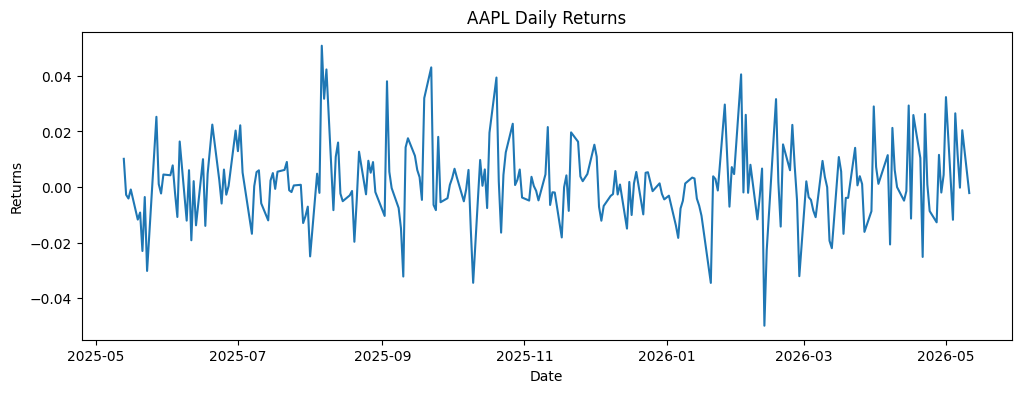

In [ ]:
#Returns over time
plt.figure(figsize=(12,4))
plt.plot(history.index, history['Return'])
plt.title('AAPL Daily Returns')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.show()

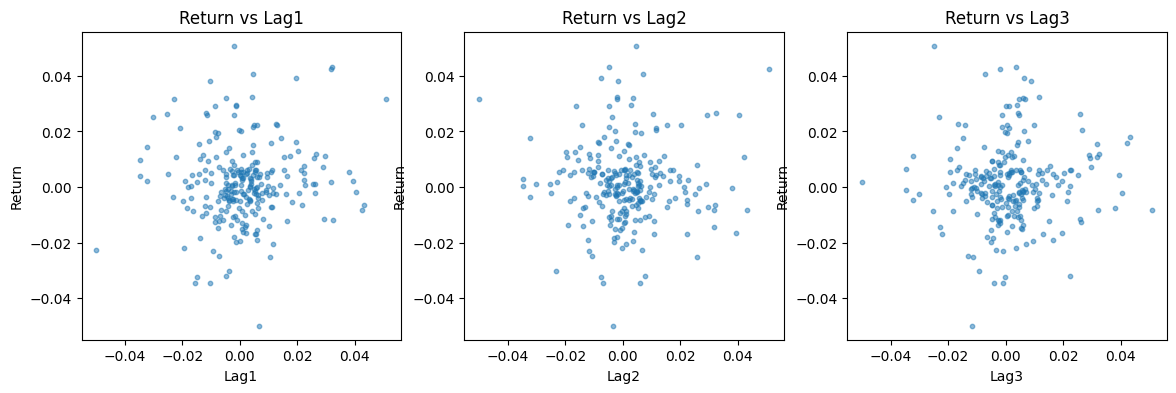

In [ ]:
#Lag correlation scatter plot
fig, axes = plt.subplots(1,3,figsize=(14,4))

for i, lag in enumerate(['Lag1', 'Lag2', 'Lag3']):
    axes[i].scatter(history[lag], history['Return'], alpha=0.5, s=10)
    axes[i].set_xlabel(lag)
    axes[i].set_ylabel('Return')
    axes[i].set_title(f'Return vs {lag}')

plt.tight_layout
plt.show()

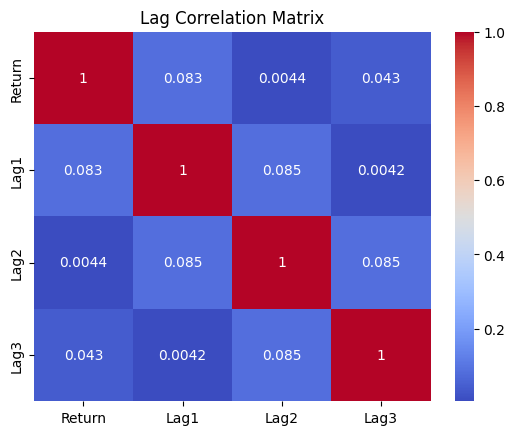

In [ ]:
#correlation heatmap
corr = history[['Return','Lag1','Lag2','Lag3']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Lag Correlation Matrix')
plt.show()